<a href="https://colab.research.google.com/github/Aryansaini-10/FUTURE_ML_02/blob/main/customer_support_ticketsipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

importing libraries

In [27]:
# Support Ticket Classification System

"""
Objective:
Build a machine learning model to classify customer support tickets
and assign priority levels using NLP techniques.

Dataset:
Customer Support Tickets Dataset

Tasks:
- Text preprocessing
- Feature extraction (TF-IDF)
- Classification (Ticket Type & Priority)
- Model evaluation
"""

'\nObjective:\nBuild a machine learning model to classify customer support tickets \nand assign priority levels using NLP techniques.\n\nDataset:\nCustomer Support Tickets Dataset\n\nTasks:\n- Text preprocessing\n- Feature extraction (TF-IDF)\n- Classification (Ticket Type & Priority)\n- Model evaluation\n'

In [1]:
import pandas as pd
import numpy as np

# NLP
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

loading data

In [4]:
df = pd.read_csv("/content/customer_support_tickets.csv")
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


Basic Data Check

In [5]:
print(df.shape)
print(df.columns)
df.info()
df.isnull().sum()

(8469, 17)
Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase

,0
Ticket ID,0
Customer Name,0
Customer Email,0
Customer Age,0
Customer Gender,0
Product Purchased,0
Date of Purchase,0
Ticket Type,0
Ticket Subject,0
Ticket Description,0


Data Visualization

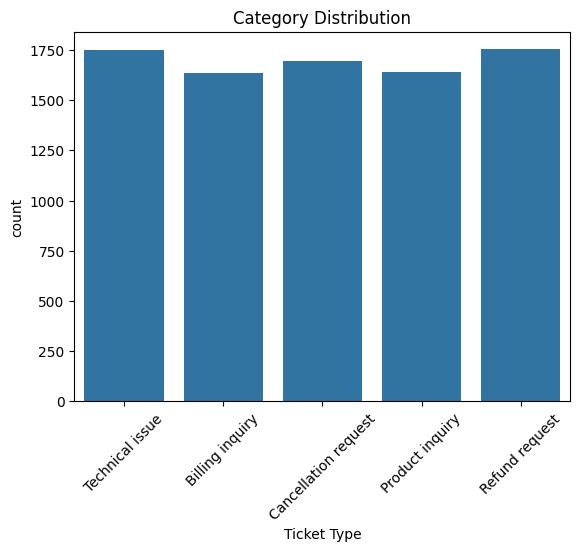

In [6]:
plt.figure()
sns.countplot(x='Ticket Type', data=df)
plt.xticks(rotation=45)
plt.title("Category Distribution")
plt.show()

Text Cleaning

In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)


In [8]:
df['ticket_text'] = df['Ticket Description'].apply(clean_text)

Feature Extraction

In [9]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['ticket_text'])

Target Variables

In [10]:
#Category Model
y_category = df['Ticket Type']

In [11]:
y_priority = df['Ticket Priority']   # high/medium/low

Train-Test Split

In [12]:
X_train, X_test, y_train_cat, y_test_cat = train_test_split(X, y_category, test_size=0.2, random_state=42)

Model Training

In [13]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC()
}

for name, model in models.items():
    model.fit(X_train, y_train_cat)
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test_cat, y_pred))


Logistic Regression
Accuracy: 0.19421487603305784

Naive Bayes
Accuracy: 0.18890200708382526

SVM
Accuracy: 0.1859504132231405


In [14]:
model_cat = LogisticRegression()
model_cat.fit(X_train, y_train_cat)

y_pred_cat = model_cat.predict(X_test)

Evaluation

In [15]:
print("Accuracy:", accuracy_score(y_test_cat, y_pred_cat))
print(classification_report(y_test_cat, y_pred_cat))

Accuracy: 0.19421487603305784
                      precision    recall  f1-score   support

     Billing inquiry       0.16      0.11      0.13       357
Cancellation request       0.19      0.20      0.19       327
     Product inquiry       0.19      0.18      0.18       316
      Refund request       0.20      0.24      0.22       345
     Technical issue       0.22      0.24      0.23       349

            accuracy                           0.19      1694
           macro avg       0.19      0.19      0.19      1694
        weighted avg       0.19      0.19      0.19      1694



Confusion Matrix

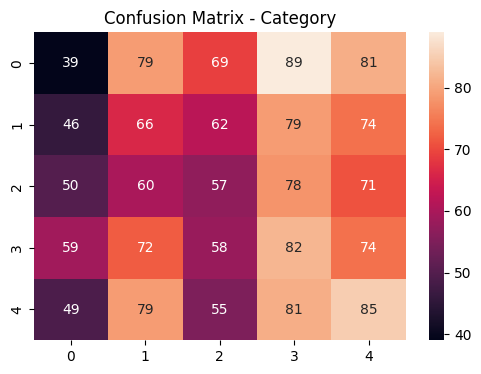

In [16]:
cm = confusion_matrix(y_test_cat, y_pred_cat)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Category")
plt.show()

Hyperparameter Tuning

In [17]:
from sklearn.model_selection import GridSearchCV

params = {'C':[0.1,1,10]}

grid = GridSearchCV(LogisticRegression(max_iter=1000), params, cv=3)
grid.fit(X_train, y_train_cat)

print("Best Params:", grid.best_params_)

Best Params: {'C': 1}


Priority Model

In [18]:
X_train, X_test, y_train_pri, y_test_pri = train_test_split(X, y_priority, test_size=0.2, random_state=42)

model_pri = LogisticRegression()
model_pri.fit(X_train, y_train_pri)

y_pred_pri = model_pri.predict(X_test)

print("Priority Accuracy:", accuracy_score(y_test_pri, y_pred_pri))

Priority Accuracy: 0.2449822904368359


Save Models

In [19]:
import joblib
joblib.dump(model_cat, 'category_model.pkl')
joblib.dump(model_pri, 'priority_model.pkl')
joblib.dump(tfidf, 'vectorizer.pkl')

['vectorizer.pkl']

Real Demo

In [20]:
def predict_ticket(text):
    cleaned = clean_text(text)
    vector = tfidf.transform([cleaned])

    category = model_cat.predict(vector)[0]
    priority = model_pri.predict(vector)[0]

    print("Ticket:", text)
    print("Predicted Category:", category)
    print("Predicted Priority:", priority)

# Example
predict_ticket("My payment failed but money got deducted")

Ticket: My payment failed but money got deducted
Predicted Category: Product inquiry
Predicted Priority: Critical


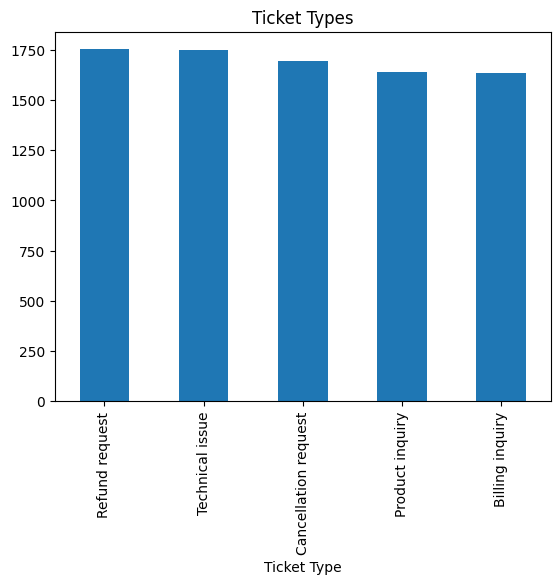

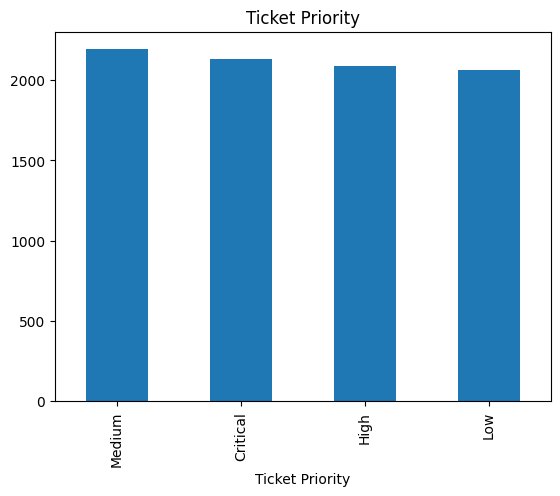

In [21]:
import matplotlib.pyplot as plt

df['Ticket Type'].value_counts().plot(kind='bar')
plt.title("Ticket Types")
plt.show()

df['Ticket Priority'].value_counts().plot(kind='bar')
plt.title("Ticket Priority")
plt.show()

In [25]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train_cat)

MultinomialNB()

In [26]:
df['text'] = df['Ticket Subject'] + " " + df['Ticket Description']